# Pemodelan Prediksi Suhu Permukaan Jawa
## Regresi Multivariat | Data CORDEX-CMIP5

---


**Dataset**: CORDEX South-East Asia (SEA)  
**Sumber**: Climate Data Store (CDS) Copernicus — https://cds.climate.copernicus.eu/  
**Area**: Pulau Jawa  

---

### Referensi Utama
- Tangang et al. (2020) — CORDEX-SEA: *An integrated regional climate model projection for Southeast Asia* — Climate Dynamics
- Li et al. (2010) — EDCDF Bias Correction — J. Hydrology
- Ghaemi et al. (2023) — Regional Temperature Projection arXiv:2504.19145

---

In [249]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

class MultivariateRegressionModel:
    def __init__(self, l2_lambda=1e-4):
        self.l2_lambda = l2_lambda
        self.weights = None
        self.bias = None

    def fit(self, X_train, y_train):
        """
        Latih Model Regresi Ridge dengan data historis dan Normal Equation
        
        Parameters:
        X_train : Matriks data fitur cuaca
        y_train : Vektor data suhu asli 
        """
        X_design = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        I = np.eye(X_design.shape[1])
        I[0,0] = 0

        theta = np.linalg.pinv(X_design.T @ X_design + self.l2_lambda * I) @ X_design.T @ y_train

        self.bias = theta[0]
        self.weights = theta[1:]

        abs_weights = np.abs(self.weights)
        pengaruh = abs_weights / (np.sum(abs_weights) + 1e-8)

        self.tabel_pengaruh_features = pd.DataFrame({
            "weight": self.weights, 
            "importance": pengaruh
            })
        return self
    
    def model_predict(self, X):
        """
        model prediksi
        """
        return X @ self.weights + self.bias
    
    def evaluate(self, X, y):
        """
        evaluasi model prediksi
        """
        y_pred = self.model_predict(X)
        residuals = y - y_pred

        mse = np.mean(residuals**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(residuals))

        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0  

        return {
            "MSE score": float(mse),
            "RMSE score": float(rmse),
            "MAE score": float(mae),
            "R2 score": float(r2)
        }
    
    def ambil_peringkat_fitur_berpengaruh(self, nama_feature):
        self.tabel_pengaruh_features['feature'] = nama_feature
        tabel_terurut = self.tabel_pengaruh_features.sort_values("importance", ascending=False)
        return tabel_terurut
    
    def save(self, model_dir):
        import os, numpy as np
        os.makedirs(model_dir, exist_ok=True)
        np.save(os.path.join(model_dir, 'weights.npy'), self.weights)
        np.save(os.path.join(model_dir, 'bias.npy'), np.array([self.bias]))
        
    
class ZScore:
    def __init__(self):
        self.mean = None 
        self.std = None 
    
    def fit(self, X):
        """ 
        Cari rata-rata ma standar deviasi
        abaikan data Nan
        cegah error pembagian 0
        """ 
        self.mean = np.nanmean(X, axis=0)
        self.std = np.nanstd(X, axis=0)
        self.std[self.std == 0] = 1.0
        return self
    
    def transform(self, X):
        """ 
        z = (x - mean) / standar deviasi
        """ 
        return (X - self.mean) / self.std
    
    def save(self, filepath):
        import numpy as np
        np.savez(filepath, mean=self.mean, std=self.std)

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})


### 1. Eksporasi Data

In [250]:
DATA_PATH   = '../data/processed/features/X_historical.csv'
TARGET_PATH = '../data/processed/targets/y_historical.csv'
RAW_PATH    = '../tmp_folder/historical_raw.csv'

df_raw = pd.read_csv(RAW_PATH, parse_dates=["time"])
df_X   = pd.read_csv(DATA_PATH, parse_dates=['time'])
df_y   = pd.read_csv(TARGET_PATH, parse_dates=['time'])

print(f'Data mentah : {df_raw.shape}')
print(f'Data fitur  : X={df_X.shape}')
print(f'Data target : y={df_y.shape}')

Data mentah : (228, 16)
Data fitur  : X=(216, 108)
Data target : y=(216, 2)


In [251]:
df_X.describe()

,time,cloud_cover,evaporation,humidity,specific_humidity,precip,pressure,sea_level_pressure,thermal_rad,solar_rad,...,humidity_roll12,pressure_roll3,pressure_roll6,pressure_roll12,solar_rad_roll3,solar_rad_roll6,solar_rad_roll12,month_sin,month_cos,temp_2m_anomaly
count,216,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,...,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,2.160000e+02,2.160000e+02,216.000000
mean,1996-12-15 17:33:20,69.642516,4.908247,81.336604,17.675083,6.704157,1005.893454,1010.025682,411.992879,220.585300,...,81.318390,1005.900324,1005.907275,1005.916799,220.529453,220.763519,220.916118,-2.672759e-17,-4.523131e-17,0.004485
min,1988-01-01 00:00:00,52.963657,2.727502,75.502045,16.010563,0.653993,1002.383540,1006.674560,387.194980,134.194500,...,79.548189,1003.289833,1004.019667,1005.101064,143.139397,162.341298,186.353990,-1.000000e+00,-1.000000e+00,-0.480507
25%,1992-06-23 12:00:00,66.818310,3.871746,80.032270,17.154692,3.884860,1005.117935,1009.262905,405.956558,188.681255,...,80.896405,1005.166145,1005.365672,1005.641834,193.436947,202.827869,215.670383,-5.915064e-01,-5.915064e-01,-0.153780
50%,1996-12-16 12:00:00,70.224625,4.789350,81.488835,17.723810,6.518428,1005.942525,1010.115485,412.625335,223.802760,...,81.264621,1005.928322,1005.932230,1005.962583,224.321790,221.390445,222.826697,-6.123234e-17,-6.123234e-17,0.021640
75%,2001-06-08 12:00:00,72.886800,5.970834,83.034966,18.216494,9.134887,1006.727710,1010.860000,418.469050,253.330180,...,81.789941,1006.680674,1006.462329,1006.127683,246.697333,240.080524,227.814116,5.915064e-01,5.915064e-01,0.152069
max,2005-12-01 00:00:00,78.335570,7.619037,85.912020,18.891539,15.000661,1008.973100,1012.823800,431.001160,308.766240,...,82.976364,1008.152480,1007.494410,1006.757668,299.030623,276.384897,238.501015,1.000000e+00,1.000000e+00,0.599548
std,NaN,4.598907,1.180416,2.186751,0.654873,3.670282,1.266420,1.210277,9.004186,39.974975,...,0.627878,1.044531,0.743454,0.358970,33.347860,23.898914,10.089051,7.087493e-01,7.087493e-01,0.222742


In [252]:
df_y.describe().round()

,time,temp_2m
count,216,216.0
mean,1996-12-15 17:33:20,26.0
min,1988-01-01 00:00:00,25.0
25%,1992-06-23 12:00:00,26.0
50%,1996-12-16 12:00:00,26.0
75%,2001-06-08 12:00:00,26.0
max,2005-12-01 00:00:00,27.0
std,NaN,0.0


In [253]:
df_raw.describe().round()

,time,cloud_cover,evaporation,humidity,specific_humidity,precip,pressure,sea_level_pressure,thermal_rad,solar_rad,wind_speed,temp_2m,temp_max_24h,temp_min_24h,wind_u,wind_v
count,228,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0
mean,1996-05-27 21:03:09.473684,70.0,5.0,81.0,18.0,7.0,1006.0,1010.0,412.0,220.0,6.0,26.0,27.0,25.0,-3.0,2.0
min,1986-01-01 00:00:00,53.0,3.0,76.0,16.0,1.0,1002.0,1007.0,387.0,134.0,3.0,25.0,26.0,25.0,-8.0,-2.0
25%,1991-09-23 12:00:00,67.0,4.0,80.0,17.0,4.0,1005.0,1009.0,406.0,189.0,5.0,26.0,27.0,25.0,-6.0,1.0
50%,1996-06-16 00:00:00,70.0,5.0,82.0,18.0,7.0,1006.0,1010.0,413.0,225.0,6.0,26.0,27.0,25.0,-5.0,2.0
75%,2001-03-08 18:00:00,73.0,6.0,83.0,18.0,9.0,1007.0,1011.0,418.0,253.0,8.0,26.0,27.0,26.0,0.0,4.0
max,2005-12-01 00:00:00,78.0,8.0,86.0,19.0,16.0,1009.0,1013.0,431.0,309.0,9.0,27.0,28.0,26.0,5.0,5.0
std,NaN,5.0,1.0,2.0,1.0,4.0,1.0,1.0,9.0,40.0,2.0,0.0,0.0,0.0,4.0,2.0


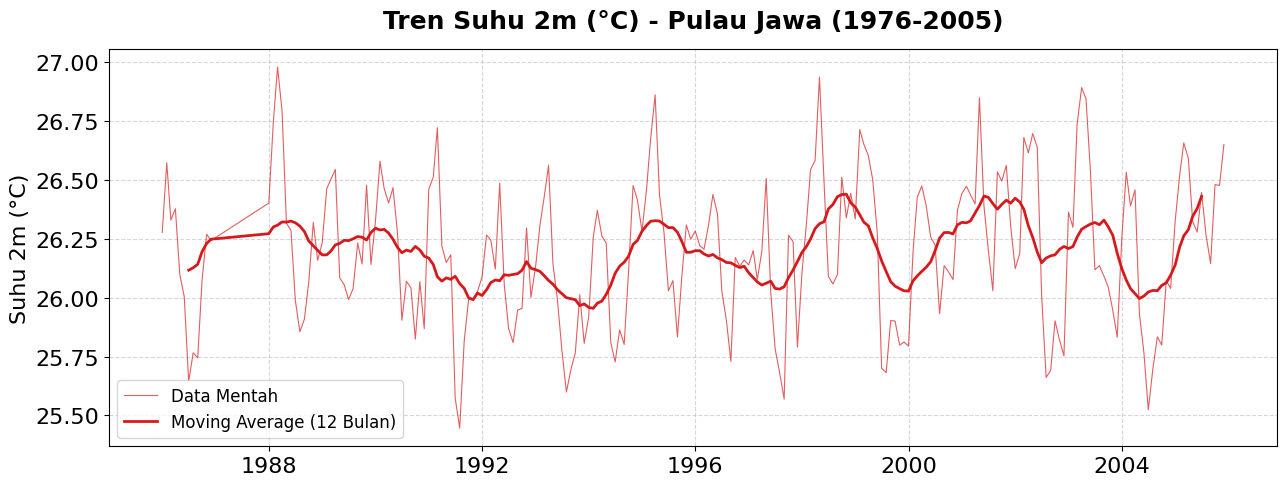

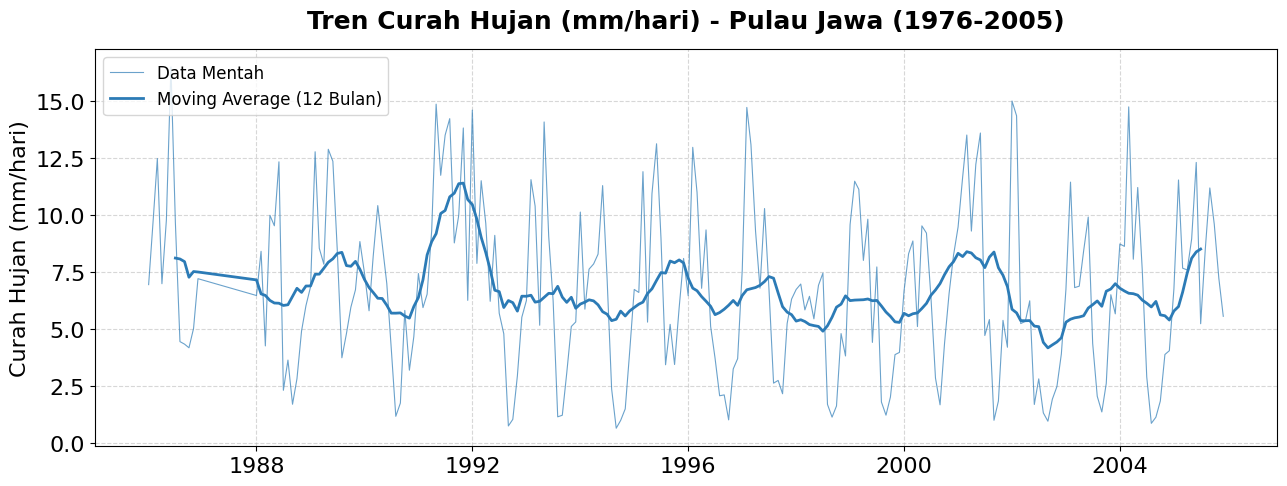

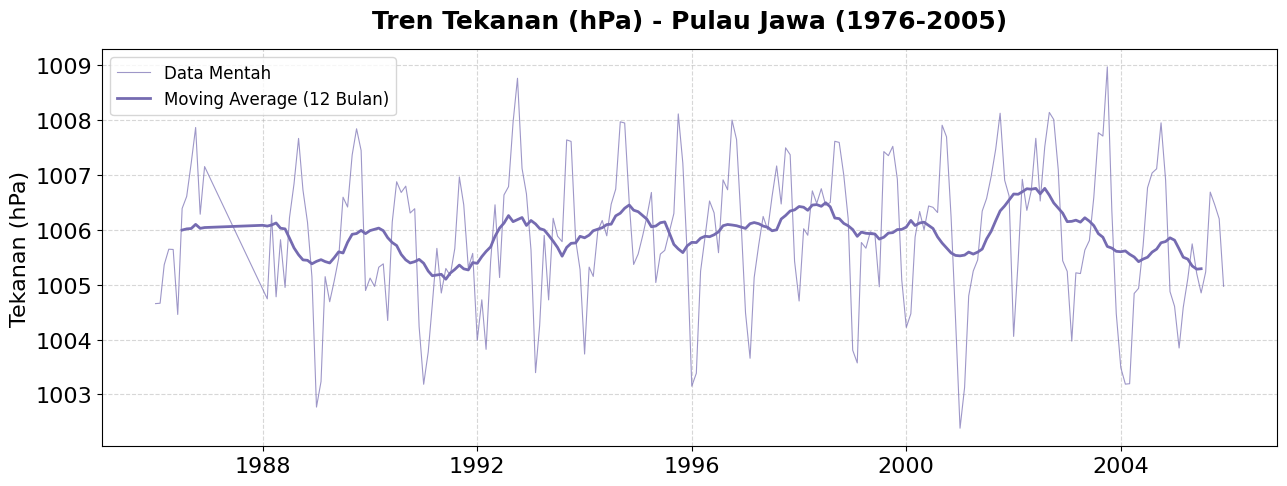

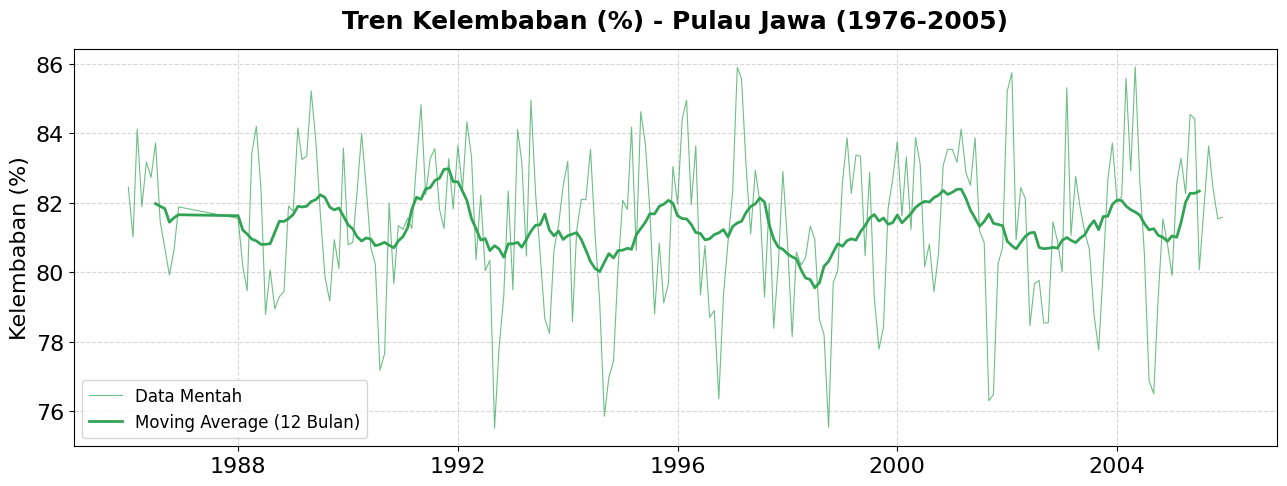

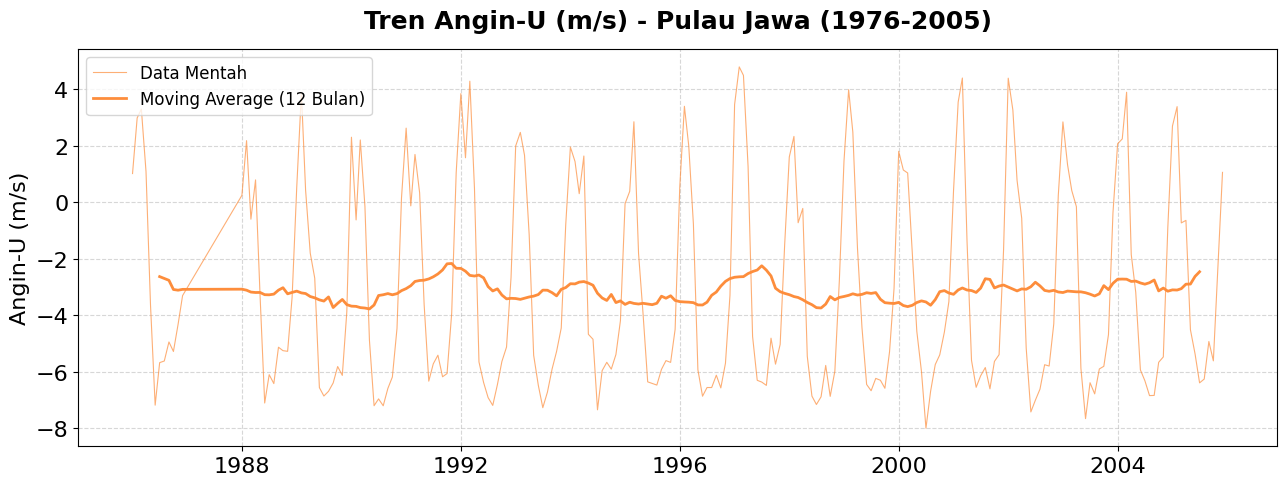

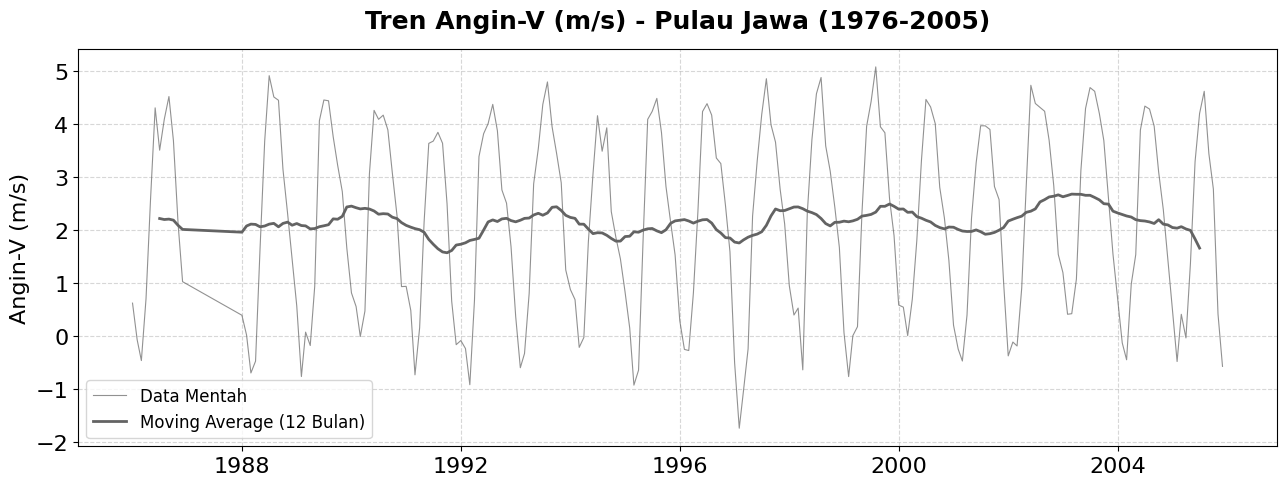

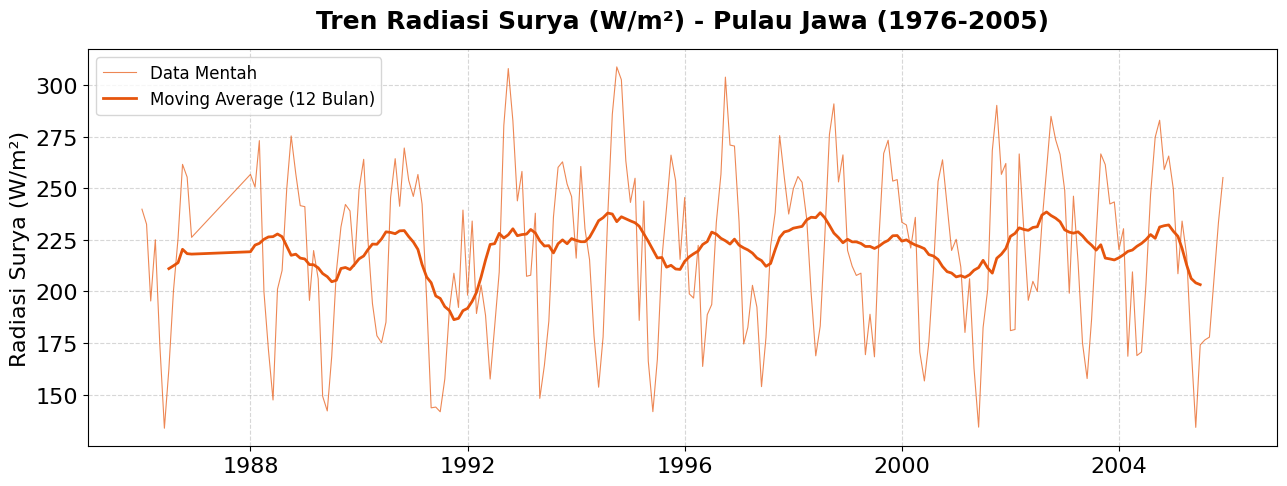

In [254]:
# Melihat persebaran data yang didapat dari CORDEX

variables = [
    ('temp_2m',   'Suhu 2m (°C)',         '#d7191c'),
    ('precip',    'Curah Hujan (mm/hari)', '#2c7bb6'),
    ('pressure',  'Tekanan (hPa)',         '#756bb1'),
    ('humidity',  'Kelembaban (%)',        '#31a354'),
    ('wind_u',    'Angin-U (m/s)',         '#fd8d3c'),
    ('wind_v',    'Angin-V (m/s)',         '#636363'),
    ('solar_rad', 'Radiasi Surya (W/m²)', '#e6550d'),
]


for col, label, color in variables:
    if col in df_raw.columns:
        fig, ax = plt.subplots(figsize=(13, 5), sharex=True)
        
        ax.plot(df_raw['time'], df_raw[col], color=color, linewidth=0.8, alpha=0.7, label='Data Mentah')
        
        roll = df_raw[col].rolling(12, center=True).mean()
        ax.plot(df_raw['time'], roll, color=color, linewidth=2.0, label='Moving Average (12 Bulan)')
        
        ax.set_ylabel(label, fontsize=16)
        ax.tick_params(axis='both', labelsize=16)
        
        ax.set_title(f'Tren {label} - Pulau Jawa (1976-2005)', fontsize=18, fontweight='bold', pad=15)
        
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=12)
        
        fig.tight_layout()
        fig.savefig(f'../results/figures/Tren_{col}_Persebaran_Features.png', dpi=150, bbox_inches='tight')
        plt.show()



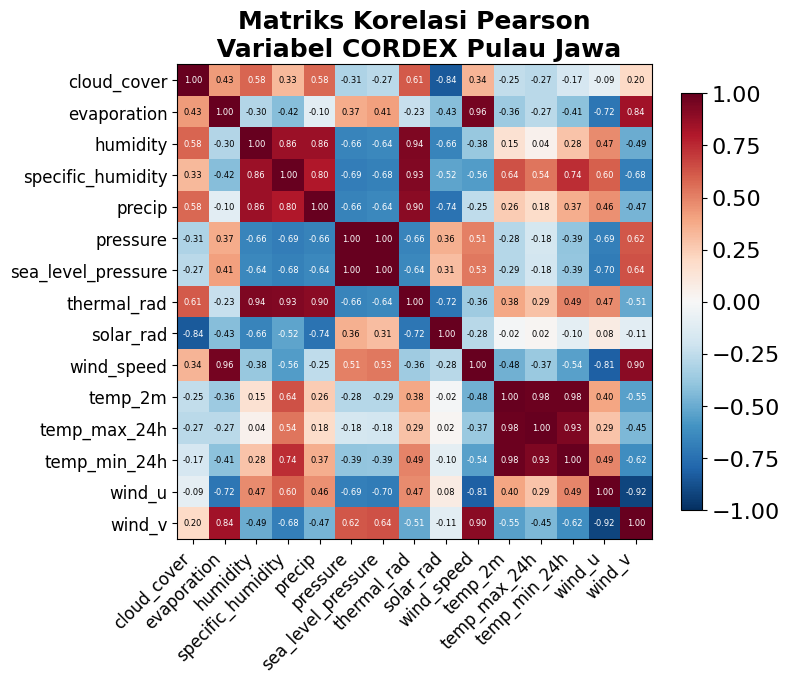

In [255]:
# Matriks Korelasi
num_cols = [c for c in df_raw.columns if c != 'time']
X_all = df_raw[num_cols].values

n_vars = X_all.shape[1]
corr_matrix = np.zeros((n_vars, n_vars))
for i in range(n_vars):
    for j in range(n_vars):
        xi = X_all[:, i] - X_all[:, i].mean()
        xj = X_all[:, j] - X_all[:, j].mean()
        denom = np.sqrt(np.sum(xi**2) * np.sum(xj**2))
        corr_matrix[i,j] = np.sum(xi * xj) / denom if denom > 0 else 0

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(num_cols, fontsize=12)

for i in range(n_vars):
    for j in range(n_vars):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriks Korelasi Pearson\n Variabel CORDEX Pulau Jawa', fontsize=18, fontweight='bold')
fig.tight_layout()
fig.savefig('../results/figures/Matriks_Korelasi_Pearson_Variabel', dpi=150, bbox_inches='tight')
plt.show()

### 2. Bias Correction (EDCDF)


In [256]:
# Menambahkan noise 
data_observasi = df_raw['temp_2m'].values + np.random.normal(0, 0.1, len(df_raw))
data_observasi_cacat = df_raw['temp_2m'].values + 1.2

# Simulasi
n_proj = 200
t_proj = np.arange(n_proj)
seasonal_proj = np.sin(2* np.pi * t_proj / 12)
trend_proj = 0.005 * t_proj
proyeksi_data_cacat = 28.0 + 1.5 * seasonal_proj + trend_proj + 1.2 + np.random.normal(0, 0.3, n_proj) 

corrector = EDCDFBiasCorrector(n_quantiles=100)
corrected = corrector.fit_transform(data_observasi, data_observasi_cacat, proyeksi_data_cacat)

print(f'Sebelum koreksi: mean={proyeksi_data_cacat.mean():.3f}°C')
print(f'Sesudah koreksi: mean={corrected.mean():.3f}°C')
print(f'Referensi hist:  mean={data_observasi.mean():.3f}°C')

Sebelum koreksi: mean=29.750°C
Sesudah koreksi: mean=28.577°C
Referensi hist:  mean=26.199°C


### 3 Feature Engineering

### 4. Persiapan Data Training

In [257]:
year = df_X['time'].dt.year

TRAIN_END = 2000
VAL_END   = 2003

mask_train = year <= TRAIN_END
mask_val   = (year > TRAIN_END) & (year <= VAL_END)
mask_test  = year > VAL_END

LEAK_COLS = [
    'temp_max_24h', 'temp_min_24h', 
    'temp_2m_roll3', 'temp_2m_roll6', 'temp_2m_roll12', 
    'temp_2m_anomaly'
]
feature_cols = [c for c in df_X.columns if c != 'time' and c not in LEAK_COLS]

X_train = df_X[mask_train][feature_cols].values
y_train = df_y[mask_train]['temp_2m'].values
X_val   = df_X[mask_val][feature_cols].values
y_val   = df_y[mask_val]['temp_2m'].values
X_test  = df_X[mask_test][feature_cols].values
y_test  = df_y[mask_test]['temp_2m'].values
t_test  = df_X[mask_test]['time'].values

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Periode train: {df_X[mask_train]["time"].min()} – {df_X[mask_train]["time"].max()}')
print(f'Periode val  : {df_X[mask_val]["time"].min()} – {df_X[mask_val]["time"].max()}')
print(f'Periode test : {df_X[mask_test]["time"].min()} – {df_X[mask_test]["time"].max()}')

Train: (156, 101) | Val: (36, 101) | Test: (24, 101)
Periode train: 1988-01-01 00:00:00 – 2000-12-01 00:00:00
Periode val  : 2001-01-01 00:00:00 – 2003-12-01 00:00:00
Periode test : 2004-01-01 00:00:00 – 2005-12-01 00:00:00


In [258]:
# Normalisasi Z-score
norm_X = ZScore()
X_train_n = norm_X.fit(X_train).transform(X_train)
X_val_n   = norm_X.transform(X_val)
X_test_n  = norm_X.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f'X train normalized: mean={X_train_n.mean():.4f} | std={X_train_n.std():.4f}')
print(f'y train: mean={y_mean:.3f}°C | std={y_std:.3f}°C')

X train normalized: mean=0.0000 | std=1.0000
y train: mean=26.176°C | std=0.291°C


### 5. Training Model : Regresi Multivariat

In [259]:
model = MultivariateRegressionModel()

print(f'Fitur: {X_train_n.shape[1]}')
print(f'Samples: {len(y_train_n)}')

Fitur: 101
Samples: 156


In [260]:
# Lakukan Training
model.fit(X_train_n, y_train_n)

print(f'Weights shape: {model.weights.shape}')
print(f'Bias: {model.bias:.4f}')

Weights shape: (101,)
Bias: -0.0000


### 6. Evaluasi Model

In [261]:
matriks_train = model.evaluate(X_train_n, y_train_n)
matriks_val = model.evaluate(X_val_n, y_val_n)
matriks_test = model.evaluate(X_test_n, y_test_n)

print(f'Train MSE: {matriks_train["MSE score"]:.6f} | RMSE: {matriks_train["RMSE score"]:.6f} | MAE score: {matriks_train["MAE score"]:.6f} | R2 Score: {matriks_train["R2 score"]:.4f}')
print(f'Val MSE: {matriks_val["MSE score"]:.6f} | RMSE: {matriks_val["RMSE score"]:.6f} | MAE score: {matriks_val["MAE score"]:.6f} | R2 Score: {matriks_val["R2 score"]:.4f}')
print(f'Test MSE: {matriks_test["MSE score"]:.6f} | RMSE: {matriks_test["RMSE score"]:.6f} | MAE score: {matriks_test["MAE score"]:.6f} | R2 Score: {matriks_test["R2 score"]:.4f}')

Train MSE: 0.000516 | RMSE: 0.022716 | MAE score: 0.018541 | R2 Score: 0.9995
Val MSE: 0.006846 | RMSE: 0.082740 | MAE score: 0.065549 | R2 Score: 0.9950
Test MSE: 0.010158 | RMSE: 0.100785 | MAE score: 0.077699 | R2 Score: 0.9915


In [262]:
print(matriks_test)
print(matriks_train)
print(matriks_val)

{'MSE score': 0.010157572700827854, 'RMSE score': 0.10078478407392583, 'MAE score': 0.07769885672009062, 'R2 score': 0.9915196948753705}
{'MSE score': 0.000516003889904278, 'RMSE score': 0.022715719004783405, 'MAE score': 0.018541208060558107, 'R2 score': 0.9994839961100958}
{'MSE score': 0.006845841867688845, 'RMSE score': 0.0827396027769583, 'MAE score': 0.06554947716916121, 'R2 score': 0.9949701407855824}


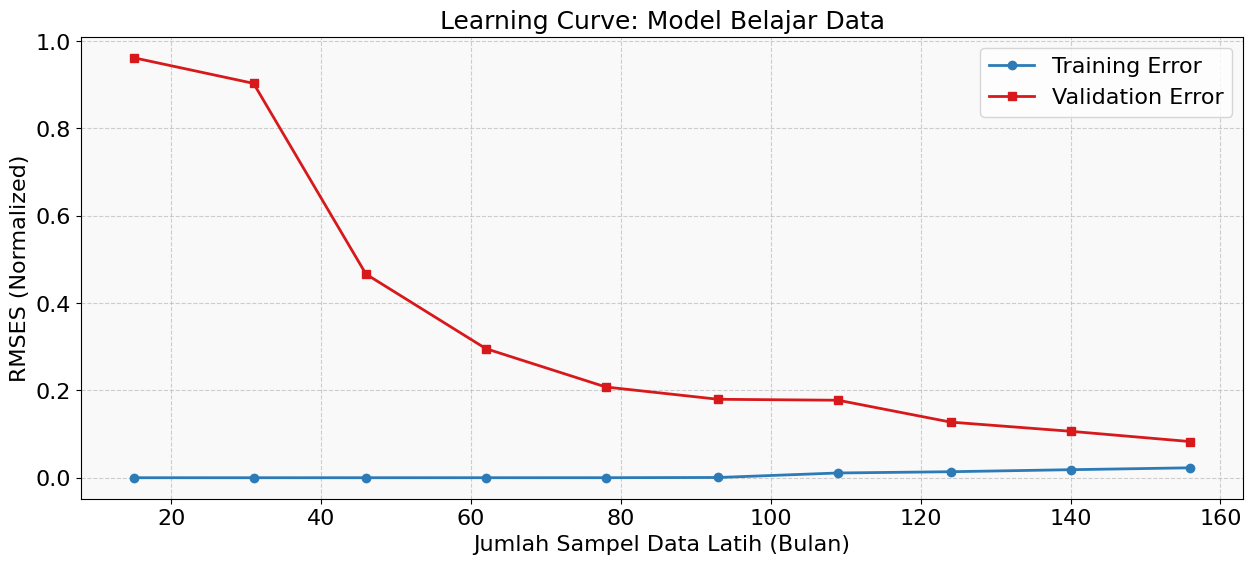

In [263]:
# Learning Curve plots
train_sizes = np.linspace(0.1, 1.0, 10)
train_rmses = []
val_rmses = []

for frac in train_sizes:
    n_samples = int(frac * len(X_train_n))
    if n_samples < 5 : 
        continue

    X_subset = X_train_n[:n_samples]
    y_subset = y_train_n[:n_samples]

    temp_model = MultivariateRegressionModel()
    temp_model.fit(X_subset, y_subset)

    pred_t = temp_model.model_predict(X_subset)
    res_t = y_subset - pred_t
    train_rmses.append(np.sqrt(np.mean(res_t**2)))

    pred_v = temp_model.model_predict(X_val_n)
    res_v = y_val_n - pred_v
    val_rmses.append(np.sqrt(np.mean(res_v**2)))

sample_counts = [int(frac * len(X_train_n)) for frac in train_sizes if int(frac * len(X_train_n)) >= 5]

fig, ax = plt.subplots(1, 1, figsize=(15, 6))

ax.plot(sample_counts, train_rmses, 'o-', linewidth=2, color='#2c7bb6', label='Training Error')
ax.plot(sample_counts, val_rmses, 's-', linewidth=2, color='#d7191c', label='Validation Error')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_facecolor('#f9f9f9')

ax.set_xlabel('Jumlah Sampel Data Latih (Bulan)', fontsize = 16)
ax.set_ylabel('RMSES (Normalized)', fontsize=16)
ax.set_title('Learning Curve: Model Belajar Data', fontsize=18)
ax.legend()

plt.show()

RMSE Baseline (Tanpa ML): 0.2261°C
RMSE Model ML (Regresi Multivariat): 0.1008°C


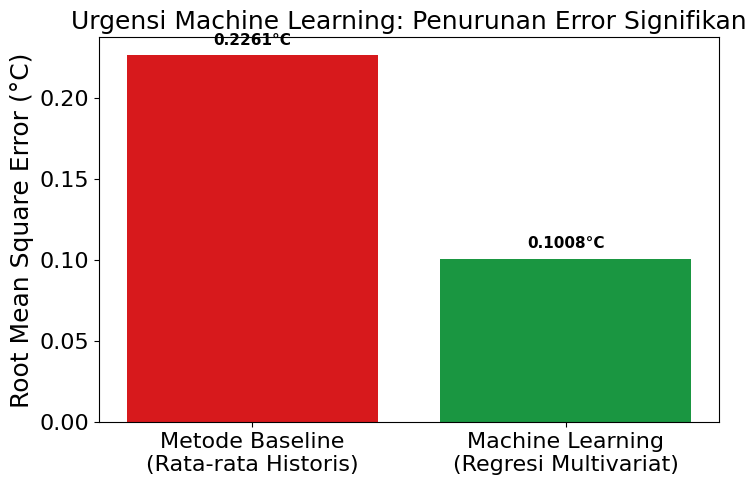

In [264]:
#Baseline Model Comparison
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = np.mean((y_test - baseline_pred))
baseline_rmse = np.sqrt(baseline_mse)

print(f'RMSE Baseline (Tanpa ML): {baseline_rmse:.4f}°C')
print(f'RMSE Model ML (Regresi Multivariat): {matriks_test["RMSE score"]:.4f}°C')

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

bars = ax.bar(['Metode Baseline\n(Rata-rata Historis)', 'Machine Learning\n(Regresi Multivariat)'], 
          [baseline_rmse, matriks_test["RMSE score"]], 
          color=['#d7191c', '#1a9641'])
ax.set_ylabel('Root Mean Square Error (°C)')
ax.set_title('Urgensi Machine Learning: Penurunan Error Signifikan')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}°C', ha='center', va='bottom', fontweight='bold')

plt.show()

### 7 Pengaruh Feature

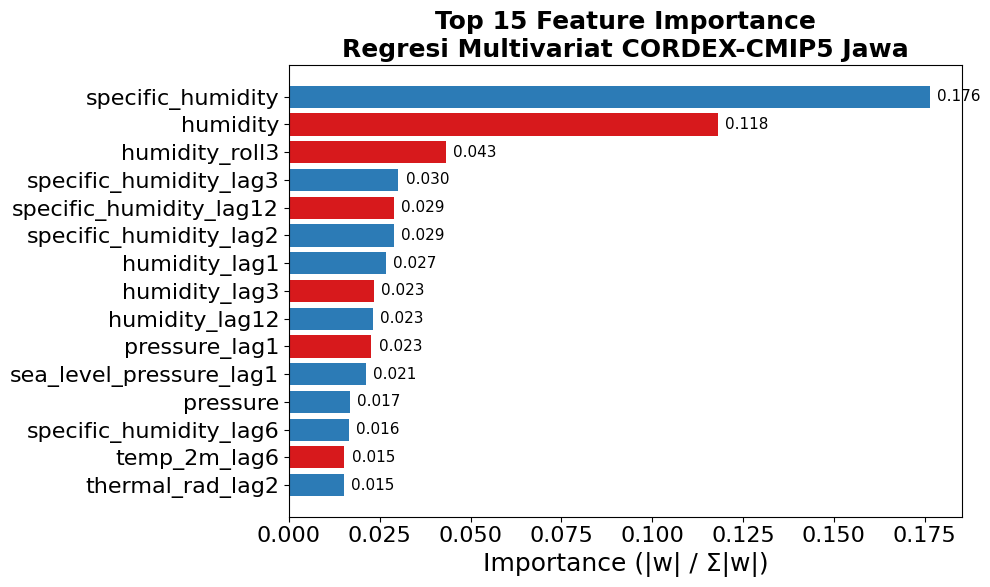

In [265]:
fi = model.ambil_peringkat_fitur_berpengaruh(feature_cols)
top15 = fi.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d7191c' if w < 0 else '#2c7bb6' for w in top15['weight']]
ax.barh(top15['feature'], top15['importance'], color=colors, edgecolor='none')
ax.set_xlabel('Importance (|w| / Σ|w|)')
ax.set_title('Top 15 Feature Importance\nRegresi Multivariat CORDEX-CMIP5 Jawa', fontweight='bold')
ax.invert_yaxis()

for i, (imp, w) in enumerate(zip(top15['importance'], top15['weight'])):
    ax.text(imp + 0.002, i, f'{imp:.3f}', va='center')

fig.tight_layout()
plt.savefig('../results/figures/Variabel_paling_berpengaruh.png', dpi=150, bbox_inches='tight')
plt.show()

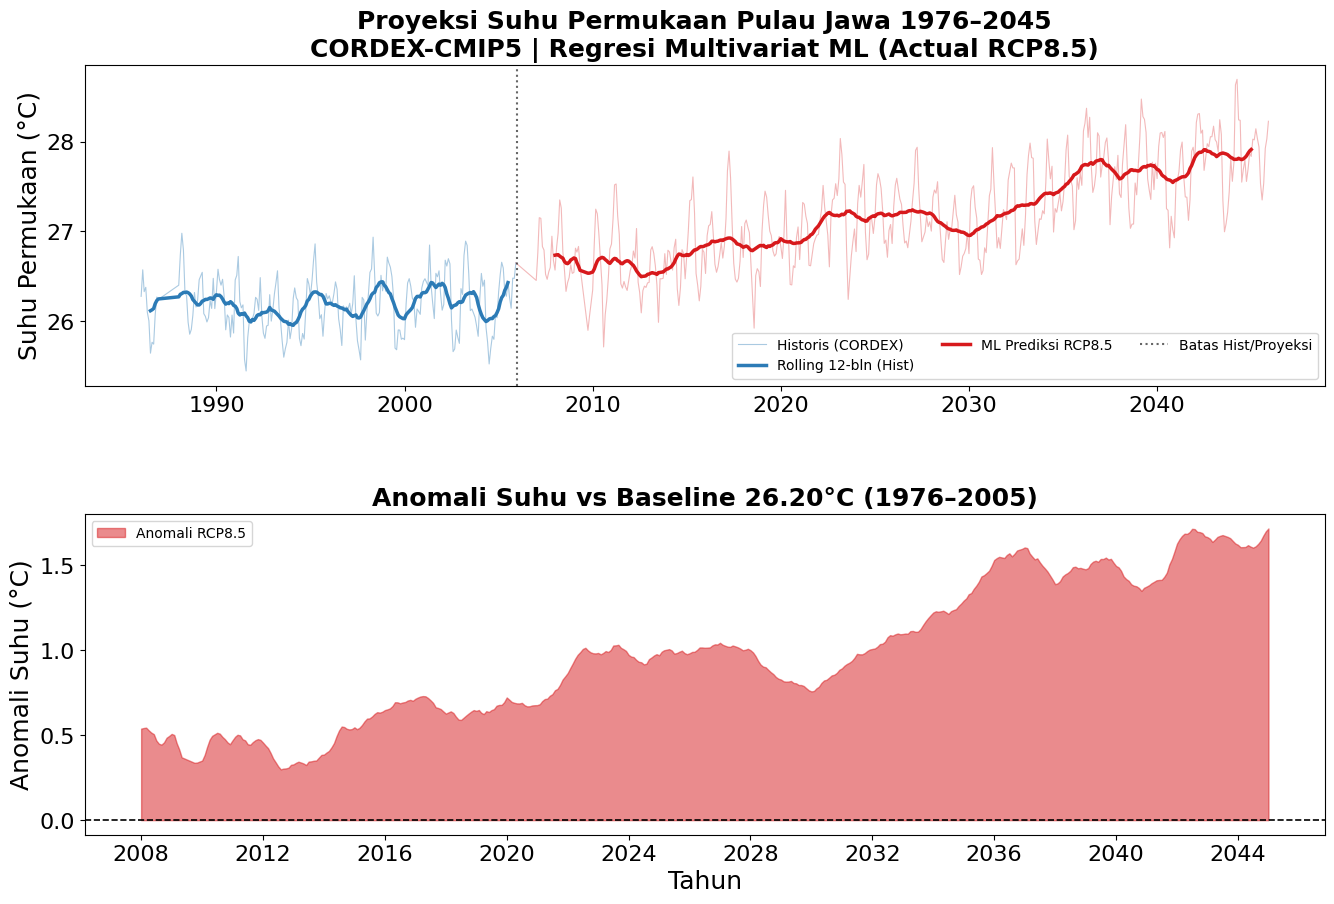

In [266]:
df_rcp85 = pd.read_csv('../data/processed/features/X_rcp85.csv')
dates_rcp85 = pd.to_datetime(df_rcp85['time'])

# 1. Feature Selection menggunakan list fitur yang identik dengan saat di-train
X_rcp85_raw = df_rcp85[feature_cols].values

# 2. Standarisasi/Z-Score Normalisasi menggunakan ZScoreNormalizer yang terlatih oleh sejarah
X_rcp85_n = norm_X.transform(X_rcp85_raw)

# 3. Inferensi MultiVariat ML Model
y_rcp85_pred_n = model.model_predict(X_rcp85_n)

# 4. Detransformasi ke representasi Suhu Derajat Celcius Nyata
y_rcp85_pred = (y_rcp85_pred_n * y_std) + y_mean

last_h_time = df_raw['time'].iloc[-1]
last_h_temp = df_raw['temp_2m'].iloc[-1]
dates_conn = pd.concat([pd.Series([last_h_time]), dates_rcp85])
y_conn = np.insert(y_rcp85_pred, 0, last_h_temp)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'hspace': 0.4})

ax = axes[0]
ax.plot(df_raw['time'], df_raw['temp_2m'], color='#2c7bb6',
        linewidth=0.8, alpha=0.4, label='Historis (CORDEX)')
roll_hist = df_raw['temp_2m'].rolling(12, center=True).mean()
ax.plot(df_raw['time'], roll_hist, color='#2c7bb6',
        linewidth=2.5, label='Rolling 12-bln (Hist)')

ax.plot(dates_conn, y_conn, color='#d7191c',
        linewidth=0.8, alpha=0.3)

roll85 = pd.Series(y_rcp85_pred).rolling(24, center=True).mean()
last_roll_h = roll_hist.dropna().iloc[-1]
last_roll_h_time = df_raw['time'].iloc[roll_hist.dropna().index[-1]]
roll85_conn_dates = pd.concat([pd.Series([last_roll_h_time]), dates_rcp85])
roll85_conn_vals = np.insert(roll85.values, 0, last_roll_h)

ax.plot(roll85_conn_dates, roll85_conn_vals, color='#d7191c',
        linewidth=2.5, label='ML Prediksi RCP8.5')

ax.axvline(pd.Timestamp('2006-01-01'), color='black', linestyle=':',
           alpha=0.6, linewidth=1.5, label='Batas Hist/Proyeksi')
ax.set_ylabel('Suhu Permukaan (°C)')
ax.set_title('Proyeksi Suhu Permukaan Pulau Jawa 1976–2045\nCORDEX-CMIP5 | Regresi Multivariat ML (Actual RCP8.5)', fontweight='bold')
ax.legend(fontsize=10, ncol=3)

baseline = df_raw['temp_2m'].mean()
ax2 = axes[1]
ax2.fill_between(dates_rcp85, 0, roll85.values - baseline, alpha=0.5, color='#d7191c', label='Anomali RCP8.5')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.set_ylabel('Anomali Suhu (°C)'); ax2.set_xlabel('Tahun')
ax2.set_title(f'Anomali Suhu vs Baseline {baseline:.2f}°C (1976–2005)', fontweight='bold')
ax2.legend(fontsize=10)

plt.savefig('../results/figures/proyeksi_suhu_jawa_2045.png', dpi=150, bbox_inches='tight')
plt.show()
